<a href="https://colab.research.google.com/github/seanperdomo/Proyecto_2_MD/blob/pipeline_sdss/sdss_misionB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Proyecto 2 - Minería de Datos
### **Estudiantes:**

*   Soleil Dayana Niño Murcia
*   Sean Paul Perdomo

### **Problema Astrofísico:**

Los astrónomos modernos no observan un solo objeto; apuntan sus telescopios a un “Campo Profundo” (un parche de cielo) y extraen todo lo que hay en él utilizando diferentes longitudes de onda.

Su misión como equipo es analizar el campo ecuatorial centrado en las coordenadas RA: 135.5, Dec: 0.5 (con un radio de 0.5 grados). Deben cartografiar esta región para separar las estrellas locales de nuestra galaxia, aislar las galaxias lejanas y descubrir cuásares enrojecidos por el polvo. Para lograrlo, deberán combinar astrometría, espectroscopía y fotometría óptica e infrarroja.

## Configuración Python

Librerias:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Misión B

Misión Estudiante B: El Cosmólogo (SDSS & MAST)
GitHub: Crea una rama (branch) en el repositorio llamada pipeline_sdss.

Extracción: Utiliza una celda de Bash para enviar una consulta SQL al SkyServer de SDSS.

Lógica de Datos: Realiza un INNER JOIN relacional entre las tablas de espectroscopía y fotometría. Extrae la clase del objeto (class), el corrimiento al rojo (z) y las magnitudes ultravioleta y verde (u, g), limitando la búsqueda exactamente a las mismas coordenadas del campo profundo de tu compañero.

Análisis: En Python, grafica el Corrimiento al Rojo vs Índice de Color (
), separando visualmente las Galaxias de los Cuásares.

Exploración Web: Utiliza la interfaz web de MAST para buscar si el Telescopio Espacial Hubble (HST) o el James Webb (JWST) han tomado imágenes de alta resolución en las coordenadas exactas de este campo profundo. Incluye una captura de pantalla o un reporte de los resultados en el repositorio. Sube tus cambios y aprueba el Pull Request de tu compañero.

Query:

```
SELECT
    s.specObjID,
    s.class,
    s.z,
    p.objID,
    p.ra,
    p.dec,
    p.u,
    p.g
FROM dbo.fGetNearbyObjEq(135.5, 0.5, 30) AS n
JOIN PhotoObj AS p ON p.objID = n.objID
JOIN SpecObj  AS s ON s.bestObjID = p.objID
WHERE p.u > -9999 AND p.g > -9999
```

*En SDSS SkyServer no se pone el cono como un WHERE ra BETWEEN manualmente, sino con la función dbo.fGetNearbyObjEq(ra, dec, radio_en_arcmin)

In [2]:
%%bash
curl -s -G "https://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch" \
  --data-urlencode "format=csv" \
  --data-urlencode "cmd=SELECT s.specObjID, s.class, s.z, p.objID, p.ra, p.dec, p.u, p.g
FROM dbo.fGetNearbyObjEq(135.5, 0.5, 30) AS n
JOIN PhotoObj AS p ON p.objID = n.objID
JOIN SpecObj AS s ON s.bestObjID = p.objID
WHERE p.u > -9999 AND p.g > -9999" \
  -o sdss_campo_profundo.csv

head -5 sdss_campo_profundo.csv

#Table1
specObjID,class,z,objID,ra,dec,u,g
14111162617285597184,GALAXY,1.771266,1237648721748033829,135.302452999488,0.238058667730445,22.08893,21.78789
4295579541995542528,GALAXY,0.7866659,1237648721748034723,135.357104905418,0.405442417390988,24.63759,24.70751
528048462793566208,STAR,0.0003306809,1237648721748165830,135.573135140145,0.331300280512834,25.30274,24.37729


Graficar redshift vs. índice de color (u-g)

In [3]:
data_B = pd.read_csv("sdss_campo_profundo.csv", comment='#')
data_B

,specObjID,class,z,objID,ra,dec,u,g
0,14111162617285597184,GALAXY,1.771266,1237648721748033829,135.302453,0.238059,22.08893,21.78789
1,4295579541995542528,GALAXY,0.786666,1237648721748034723,135.357105,0.405442,24.63759,24.70751
2,528048462793566208,STAR,0.000331,1237648721748165830,135.573135,0.331300,25.30274,24.37729
3,4296447052223895552,GALAXY,0.559920,1237648722285036587,135.661323,0.763813,23.68884,22.77421
4,529302730951387136,QSO,2.254498,1237648722285101461,135.801546,0.652386,19.65300,19.18305
...,...,...,...,...,...,...,...,...
247,528063306200541184,STAR,0.000288,1237648721748033701,135.350164,0.367496,19.49835,18.55312
248,14111164541430945792,QSO,1.914762,1237648721748034185,135.269074,0.244038,23.60324,22.60034
249,4296448151735523328,GALAXY,0.542596,1237648722285101688,135.681058,0.752755,23.82005,22.52938
250,529287337788598272,GALAXY,0.521358,1237648722285101739,135.705723,0.817465,24.25746,23.34999


In [4]:
# Crear columna de índice de color u - g
data_B['u-g'] = data_B['u'] - data_B['g']
data_B

,specObjID,class,z,objID,ra,dec,u,g,u-g
0,14111162617285597184,GALAXY,1.771266,1237648721748033829,135.302453,0.238059,22.08893,21.78789,0.30104
1,4295579541995542528,GALAXY,0.786666,1237648721748034723,135.357105,0.405442,24.63759,24.70751,-0.06992
2,528048462793566208,STAR,0.000331,1237648721748165830,135.573135,0.331300,25.30274,24.37729,0.92545
3,4296447052223895552,GALAXY,0.559920,1237648722285036587,135.661323,0.763813,23.68884,22.77421,0.91463
4,529302730951387136,QSO,2.254498,1237648722285101461,135.801546,0.652386,19.65300,19.18305,0.46995
...,...,...,...,...,...,...,...,...,...
247,528063306200541184,STAR,0.000288,1237648721748033701,135.350164,0.367496,19.49835,18.55312,0.94523
248,14111164541430945792,QSO,1.914762,1237648721748034185,135.269074,0.244038,23.60324,22.60034,1.00290
249,4296448151735523328,GALAXY,0.542596,1237648722285101688,135.681058,0.752755,23.82005,22.52938,1.29067
250,529287337788598272,GALAXY,0.521358,1237648722285101739,135.705723,0.817465,24.25746,23.34999,0.90747


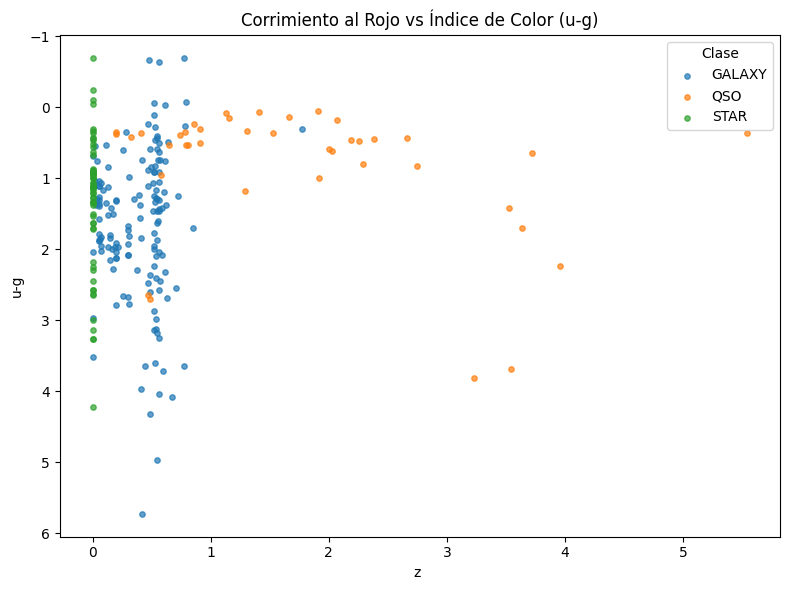

In [5]:
# Graficar agrupando por clase de objeto
plt.figure(figsize=(8, 6))

# Agrupar y graficar cada clase con un color diferente
for name, group in data_B.groupby('class'):
    plt.scatter(group['z'], group['u-g'], s=15, alpha=0.7, label=name)

plt.ylabel('u-g')
plt.xlabel('z ')
plt.title('Corrimiento al Rojo vs Índice de Color (u-g)')
plt.gca().invert_yaxis()
plt.legend(title='Clase')
plt.tight_layout()
plt.savefig('cmd_2.png')
plt.show()